## Calculate the sentiment of the band/artist pages (it is OK to work with the sub-network of artists-with-genre) and describe your findings using stats and visualization, inspired by the first exercise of week 8.

In [1]:
import re
import os
import io
import time
import math
import json
import requests
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import mwparserfromhell

%matplotlib inline

GRAPH_PATH = "rock_network_with_communities.graphml"
OUTPUT_GRAPH = "rock_network_with_sentiment.graphml"

# Wikipedia API settings
WIKI_API = "https://en.wikipedia.org/w/api.php"
USER_AGENT = "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/142.0.0.0 Safari/537.36"
SESSION = requests.Session()
SESSION.headers.update({"User-Agent": USER_AGENT})


In [6]:
def download_labmt() -> dict:
    """Download the LabMT word list (TSV) and return dict: word -> happiness score (float)."""
    # Direct link to PLOS ONE supplementary data for 'Temporal Patterns of Happiness and Information...'
    url = "https://journals.plos.org/plosone/article/file?type=supplementary&id=info:doi/10.1371/journal.pone.0026752.s001"
    r = SESSION.get(url, timeout=60)
    r.raise_for_status()
    text = r.text
    labmt = {}
    # File has a header line; columns include 'word' and 'happiness_average' (or similar)
    lines = text.splitlines()
    if lines:

        word_idx=0
        happ_idx = 2
        for line in lines[3:]:
            parts = line.rstrip("\n").split("\t")
            if len(parts) <= max(word_idx, happ_idx):
                continue
            w = parts[word_idx].strip().lower()
            try:
                s = float(parts[happ_idx])
            except ValueError:
                continue
            if w:
                labmt[w] = s
    return labmt

labmt = download_labmt()
len(labmt), list(list(labmt.items())[:5])


(10222,
 [('laughter', 8.5),
  ('happiness', 8.44),
  ('love', 8.42),
  ('happy', 8.3),
  ('laughed', 8.26)])

In [7]:

def sentiment_score(tokens, labmt, drop_neutral=False, neutral_low=4.0, neutral_high=6.0):
    """
    Compute LabMT-style sentiment score for a list of lowercase tokens.
    If drop_neutral=True, words with happiness in [neutral_low, neutral_high] are ignored.
    Returns np.nan if no scored tokens remain.
    """
    scores = []
    for t in tokens:
        s = labmt.get(t)
        if s is None:
            continue
        if drop_neutral and (neutral_low <= s <= neutral_high):
            continue
        scores.append(s)
    if not scores:
        return np.nan
    return float(np.mean(scores))


In [13]:

def fetch_wikitext(title: str) -> str:
    params = {
        "action": "query",
        "format": "json",
        "prop": "revisions",
        "rvprop": "content",
        "rvslots": "main",
        "titles": title,
    }
    r = SESSION.get(WIKI_API, params=params, timeout=30)
    r.raise_for_status()
    data = r.json()
    pages = data.get("query", {}).get("pages", {})
    for _, page in pages.items():
        revs = page.get("revisions")
        if not revs:
            return ""
        return revs[0].get("slots", {}).get("main", {}).get("*", "")
    return ""


In [16]:

# Load the graph (only local file dependency)
G = nx.read_graphml(GRAPH_PATH)
print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")

# Work on sub-network of artists that have a 'genres' attribute
nodes_with_genre = [n for n in G.nodes if G.nodes[n].get("genres")]
print(f"Artists with genres: {len(nodes_with_genre)}")

def get_page_text_for_node(n):
    # Prefer any stored text attributes if present
    for key in ["wikitext", "page_text", "text", "content"]:
        v = G.nodes[n].get(key)
        if v and isinstance(v, str) and len(v) > 50:
            return v
    # Otherwise fetch from Wikipedia
    title = str(n)
    wt = fetch_wikitext(title)
    return wt or ""

sentiment_map = {}
missing_text = 0

for i, n in enumerate(nodes_with_genre, 1):
    raw = get_page_text_for_node(n)
    if not raw:
        missing_text += 1
        sentiment_map[n] = np.nan
        continue
    # Strip wikitext to plain text
    plain = mwparserfromhell.parse(raw).strip_code()
    tokens = re.findall(r"[a-zA-Z']+", plain.lower())
    score = sentiment_score(tokens, labmt, drop_neutral=False)
    sentiment_map[n] = score
    G.nodes[n]["sentiment"] = score
    if i % 50 == 0:
        print(f"Processed {i}/{len(nodes_with_genre)}")

print(f"Pages with missing/empty text: {missing_text}")


Nodes: 484, Edges: 7267
Artists with genres: 481
Processed 50/481
Processed 100/481
Processed 150/481
Processed 200/481
Processed 250/481
Processed 300/481
Processed 350/481
Processed 400/481
Processed 450/481
Pages with missing/empty text: 0


In [18]:
# Gather finite sentiment values
vals = np.array([v for v in sentiment_map.values() if isinstance(v, (int, float)) and not np.isnan(v)])

print(f"Valid sentiment pages: {len(vals)}")
if len(vals) == 0:
    raise RuntimeError("No valid sentiment values computed. Ensure pages have retrievable text.")

mean_s = float(np.mean(vals))
median_s = float(np.median(vals))
var_s = float(np.var(vals, ddof=1)) if len(vals) > 1 else float("nan")
q25 = float(np.percentile(vals, 25))
q75 = float(np.percentile(vals, 75))

summary = {
    "mean": round(mean_s, 3),
    "median": round(median_s, 3),
    "variance": round(var_s, 3) if not math.isnan(var_s) else None,
    "q25": round(q25, 3),
    "q75": round(q75, 3),
}
summary


Valid sentiment pages: 481


{'mean': 5.532, 'median': 5.531, 'variance': 0.003, 'q25': 5.496, 'q75': 5.569}

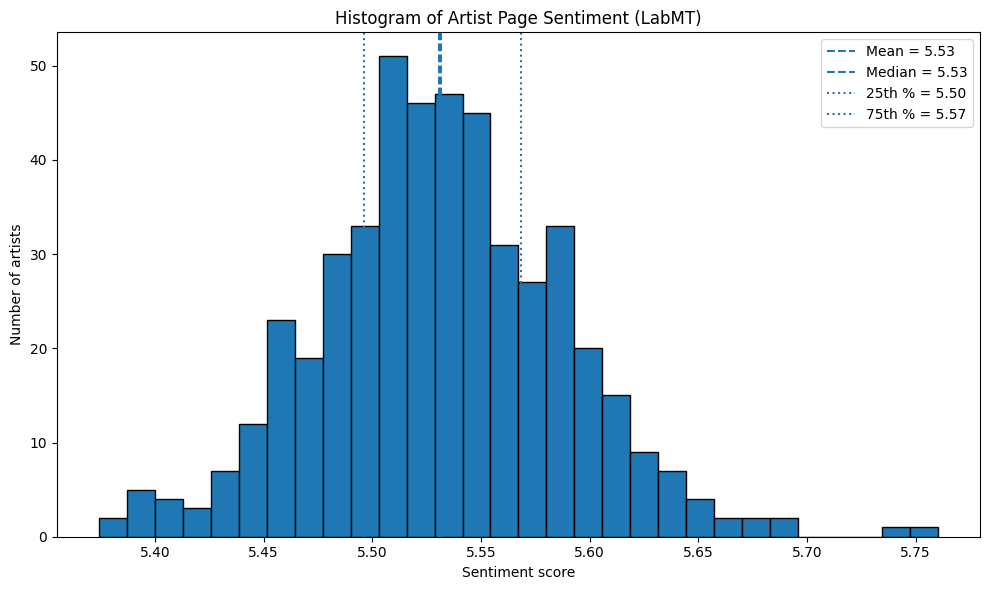

In [19]:
plt.figure(figsize=(10,6))
plt.hist(vals, bins=30, edgecolor="black")
plt.axvline(mean_s, linestyle="--", label=f"Mean = {mean_s:.2f}")
plt.axvline(median_s, linestyle="--", label=f"Median = {median_s:.2f}")
plt.axvline(q25, linestyle=":", label=f"25th % = {q25:.2f}")
plt.axvline(q75, linestyle=":", label=f"75th % = {q75:.2f}")
plt.title("Histogram of Artist Page Sentiment (LabMT)")
plt.xlabel("Sentiment score")
plt.ylabel("Number of artists")
plt.legend()
plt.tight_layout()


In [22]:
# Build sorted list of (artist, score)
pairs = [(n, s) for n, s in sentiment_map.items() if isinstance(s, (int, float)) and not np.isnan(s)]
pairs_sorted = sorted(pairs, key=lambda x: x[1], reverse=True)

top10_happy = pairs_sorted[:10]
top10_sad = pairs_sorted[-10:]

print("Top 10 happiest pages:")
for n, s in top10_happy:
    print(f"  {n}: {s:.3f}")
print("\nTop 10 saddest pages:")
for n, s in top10_sad:
    print(f"  {n}: {s:.3f}")


Top 10 happiest pages:
  Lenny Kravitz: 5.760
  Tracy Chapman: 5.741
  Michael Martin Murphey: 5.695
  The Boxtones: 5.690
  Fun (band): 5.674
  The Cardigans: 5.670
  Train (band): 5.668
  Royal Blood (band): 5.667
  Counting Crows: 5.652
  Simple Plan: 5.648

Top 10 saddest pages:
  W.A.S.P. (band): 5.402
  Quiet Riot: 5.401
  Pantera: 5.400
  Canned Heat: 5.398
  Skid Row (American band): 5.398
  Sex Pistols: 5.396
  Five Finger Death Punch: 5.396
  Rage Against the Machine: 5.393
  Marilyn Manson: 5.385
  Gary Glitter: 5.374


### Sentiment results overview

The sentiment distribution of artist Wikipedia pages is **high and tightly clustered**:

| Metric | Value |
|---|---|
| Mean | 5.532 |
| Median | 5.531 |
| 25% | 5.496 |
| 75% | 5.569 |
| Variance | 0.003 |

A LabMT score above ~5 indicates positive language, so most pages lean **consistently positive**, with very little spread. This fits Wikipedia’s tone - career achievements, awards, and legacy tend to dominate over conflict or tragedy.


### Summary

Wikipedia biographies for rock artists tend to use **neutral-to-positive language**, focusing on career highlights. A few controversial or politically charged acts pull sentiment down, but the overall emotional tone remains upbeat and consistent.


[0, 1, 2, 3, 4, 5]


,community,n_total,n_with_sent,coverage,mean,median,q25,q75,sd,delta_vs_global,top3,bottom3
5,5,3,3,1.0,6.332,6.330,6.291,6.372,0.082,0.067,"[(Funkadelic, 6.415), (Parliament-Funkadelic, ...","[(Parliament (band), 6.252), (Parliament-Funka..."
2,2,55,55,1.0,6.298,6.306,6.242,6.355,0.127,0.033,"[(Dallas Green (musician), 6.58), (Tracy Chapm...","[(Disturbed (band), 5.982), (Breaking Benjamin..."
1,1,147,147,1.0,6.288,6.303,6.235,6.369,0.124,0.024,"[(Fun (band), 6.578), (Train (band), 6.546), (...","[(Marilyn Manson, 5.841), (Rage Against the Ma..."
3,3,150,150,1.0,6.287,6.267,6.217,6.356,0.116,0.022,"[(The Boxtones, 6.749), (Lenny Kravitz, 6.643)...","[(Traffic (band), 5.966), (Bill Haley & His Co..."
4,4,40,40,1.0,6.277,6.279,6.247,6.342,0.124,0.012,"[(Kenny Loggins, 6.476), (Chicago (band), 6.45...","[(Gary Glitter, 5.886), (Meat Loaf, 5.965), (L..."
0,0,89,89,1.0,6.161,6.184,6.061,6.320,0.270,-0.104,"[(Greta Van Fleet, 6.529), (Steve Vai, 6.483),...","[(Poison (American band), 4.18), (Five Finger ..."



Global sentiment mean = 6.265 (sd=0.166) over 484 artists.


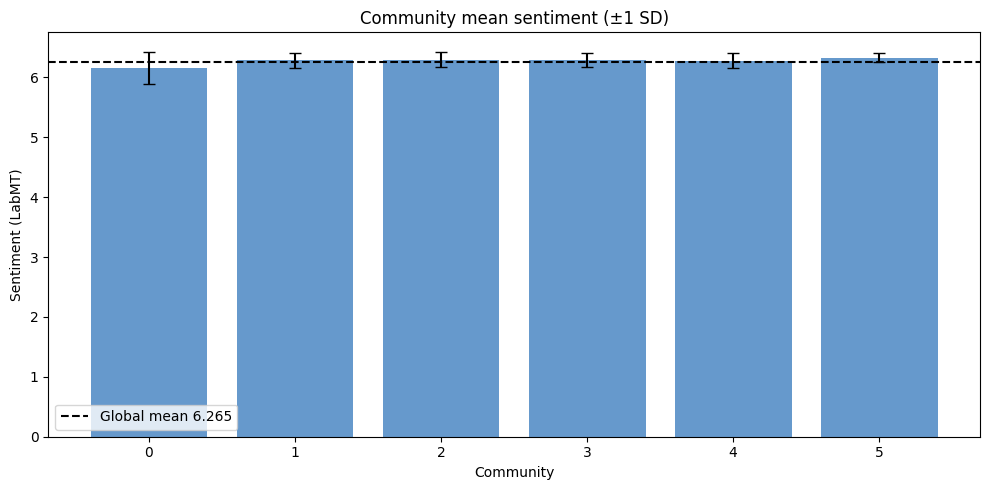


Interpretation:
 - Highest mean: community 5 at 6.332 (n=3/3 coverage=1.00).
 - Lowest mean: community 0 at 6.161 (n=89/89 coverage=1.00).
 - Spread: 0.171.
 - Top examples in best community: [('Funkadelic', 6.415), ('Parliament-Funkadelic', 6.33), ('Parliament (band)', 6.252)]
 - Bottom examples in worst community: [('Poison (American band)', 4.18), ('Five Finger Death Punch', 5.798), ('Quiet Riot', 5.814)]


In [20]:
# Sentiment per community + compact summary and visualization (robust to string-typed attributes)

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict

GRAPH_PATH = "rock_network_with_communities_and_sentiment.graphml"
G = nx.read_graphml(GRAPH_PATH)

def _as_comm(c):
    try:
        return int(c)
    except Exception:
        return c

def _to_float(x):
    if x is None:
        return None
    try:
        v = float(x)
        if np.isnan(v):
            return None
        return v
    except (TypeError, ValueError):
        return None

# Group sentiments by community and track total membership size
groups = defaultdict(list)      # comm -> list of (node, sentiment)
counts_by_comm = defaultdict(int)

for n, attrs in G.nodes(data=True):
    c = _as_comm(attrs.get("community"))
    if c is None:
        continue
    counts_by_comm[c] += 1
    s = _to_float(attrs.get("sentiment"))
    if s is not None:
        groups[c].append((n, s))

# Global sentiment over all nodes that have a sentiment
all_sents = [s for pairs in groups.values() for (_, s) in pairs]
if not all_sents:
    raise RuntimeError("Found no numeric 'sentiment' values. Ensure the graph contains the attribute or adjust attribute name.")

global_mean = float(np.mean(all_sents))
global_sd = float(np.std(all_sents, ddof=1)) if len(all_sents) > 1 else float("nan")

# Build per-community summary
summary_rows = []
print(sorted(counts_by_comm.keys(), key=lambda x: (isinstance(x, str), x)))
for c in sorted(counts_by_comm.keys(), key=lambda x: (isinstance(x, str), x)):
    sents = [s for (_, s) in groups.get(c, [])]
    n_total = counts_by_comm[c]
    n_with_sent = len(sents)
    if n_with_sent:
        mean = float(np.mean(sents))
        median = float(np.median(sents))
        q25 = float(np.percentile(sents, 25))
        q75 = float(np.percentile(sents, 75))
        sd = float(np.std(sents, ddof=1)) if n_with_sent > 1 else float("nan")
    else:
        mean = median = q25 = q75 = sd = float("nan")

    top3 = sorted(groups.get(c, []), key=lambda x: x[1], reverse=True)[:3]
    bottom3 = sorted(groups.get(c, []), key=lambda x: x[1])[:3]

    summary_rows.append({
        "community": c,
        "n_total": n_total,
        "n_with_sent": n_with_sent,
        "coverage": round(n_with_sent / n_total, 3) if n_total else 0.0,
        "mean": round(mean, 3) if not np.isnan(mean) else None,
        "median": round(median, 3) if not np.isnan(median) else None,
        "q25": round(q25, 3) if not np.isnan(q25) else None,
        "q75": round(q75, 3) if not np.isnan(q75) else None,
        "sd": round(sd, 3) if not np.isnan(sd) else None,
        "delta_vs_global": round((mean - global_mean), 3) if not np.isnan(mean) else None,
        "top3": [(n, round(s, 3)) for (n, s) in top3],
        "bottom3": [(n, round(s, 3)) for (n, s) in bottom3],
    })

import pandas as pd
summary_df = pd.DataFrame(summary_rows).sort_values("mean", ascending=False, na_position="last")
display(summary_df)


print(f"\nGlobal sentiment mean = {global_mean:.3f} (sd={global_sd:.3f}) over {len(all_sents)} artists.")

# Bar plot: community means ±1 SD, with global mean line
valid_rows = [r for r in summary_rows if r["mean"] is not None]
comm_ids = [str(r["community"]) for r in valid_rows]
means = [r["mean"] for r in valid_rows]
errs = [r["sd"] if r["sd"] is not None else 0.0 for r in valid_rows]

plt.figure(figsize=(10, 5))
plt.bar(comm_ids, means, yerr=errs, capsize=4, color="#6699cc")
plt.axhline(global_mean, color="k", linestyle="--", label=f"Global mean {global_mean:.3f}")
plt.xlabel("Community")
plt.ylabel("Sentiment (LabMT)")
plt.title("Community mean sentiment (±1 SD)")
plt.legend()
plt.tight_layout()
plt.show()

# Quick textual interpretation helpers
if valid_rows:
    best = max(valid_rows, key=lambda r: r["mean"])
    worst = min(valid_rows, key=lambda r: r["mean"])
    spread = best["mean"] - worst["mean"]
    print("\nInterpretation:")
    print(f" - Highest mean: community {best['community']} at {best['mean']:.3f} (n={best['n_with_sent']}/{best['n_total']} coverage={best['coverage']:.2f}).")
    print(f" - Lowest mean: community {worst['community']} at {worst['mean']:.3f} (n={worst['n_with_sent']}/{worst['n_total']} coverage={worst['coverage']:.2f}).")
    print(f" - Spread: {spread:.3f}.")
    print(f" - Top examples in best community: {best['top3']}")
    print(f" - Bottom examples in worst community: {worst['bottom3']}")